Model Coefficients: [ 0.03803675 -0.36798516  0.0641666 ]
Mean Squared Error: 679.6779411453056
Mean Absolute Error: 22.566732903802155
R-squared: -0.0010268497947907296


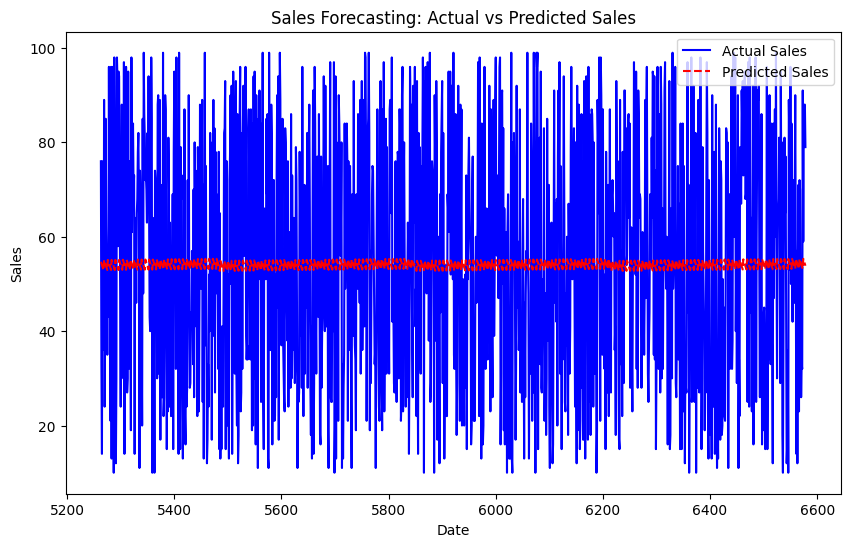

Model saved to 'outputs/models/sales_forecasting_model.pkl'


In [1]:

# 03 - Sales Forecasting Model

## Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import pickle


## Step 2: Load the Cleaned Dataset

# Load the cleaned dataset
df = pd.read_csv('../data/cleaned_sales_data.csv')
df.head()


## Step 3: Split the Data into Training and Testing Sets

# Features: Month, DayOfWeek, and Holiday
X = df[['Month', 'DayOfWeek', 'Holiday']]
# Target: Sales
y = df['Sales']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


## Step 4: Train the Model

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Print model coefficients
print(f"Model Coefficients: {model.coef_}")


## Step 5: Make Predictions

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')


## Step 6: Visualize the Predictions

# Visualize actual vs predicted sales
plt.figure(figsize=(10, 6))
plt.plot(y_test.index, y_test, label='Actual Sales', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted Sales', color='red', linestyle='--')
plt.legend()
plt.title('Sales Forecasting: Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()


## Step 7: Save the Model

# Save the trained model using pickle
with open('../outputs/models/sales_forecasting_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Model saved to 'outputs/models/sales_forecasting_model.pkl'")


## Step 8: Load the Saved Model (Optional)

# Load the saved model from the file
with open('../outputs/models/sales_forecasting_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Make predictions using the loaded model
y_pred_loaded = loaded_model.predict(X_test)


